# Breast Ultrasound Image Classification
### Deep Learning with ResNet-50 | BUSI Dataset 

## Install Dependencies

In [1]:
# !pip install torch torchvision scikit-learn matplotlib seaborn pillow
import torch, torchvision, sklearn, matplotlib, seaborn, PIL
print("torch      :", torch.__version__)
print("torchvision:", torchvision.__version__)
print("sklearn    :", sklearn.__version__)
print("GPU available:", torch.cuda.is_available())

torch      : 2.9.0+cu126
torchvision: 0.24.0+cu126
sklearn    : 1.6.1
GPU available: True


## Imports

In [2]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
)
from PIL import Image

print("All imports successful ✓")

All imports successful ✓


## Configuration

In [3]:
CONFIG = {
    "data_dir"             : "/kaggle/input/datasets/aryashah2k/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT",  
    "image_size"           : 224,
    "batch_size"           : 32,
    "num_epochs"           : 40,      
    "learning_rate"        : 5e-5,       
    "weight_decay"         : 1e-4, 
    "dropout"              : 0.5,    
    "early_stop_patience"  : 7,         
    "freeze_layer4"        : False,   
    "num_classes"          : 3,
    "seed"                 : 42,
    "device"               : "cuda" if torch.cuda.is_available() else "cpu",
    "class_names"          : ["benign", "malignant", "normal"],
    "focal_gamma"          : 2.0,
    "focal_alpha"          : [0.40, 0.40, 0.20],   # equal weight for benign & malignant
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

print(f"Device         : {CONFIG['device']}")
print(f"Classes        : {CONFIG['class_names']}")
print(f"Learning rate  : {CONFIG['learning_rate']}  (halved vs previous)")
print(f"Weight decay   : {CONFIG['weight_decay']}")
print(f"Dropout        : {CONFIG['dropout']}")
print(f"Early stop     : patience = {CONFIG['early_stop_patience']}")
print(f"Freeze layer4  : {CONFIG['freeze_layer4']}  (layer4 + FC both trainable)")

Device         : cuda
Classes        : ['benign', 'malignant', 'normal']
Learning rate  : 5e-05  (halved vs previous)
Weight decay   : 0.0001
Dropout        : 0.5
Early stop     : patience = 7
Freeze layer4  : False  (layer4 + FC both trainable)


## Dataset Class

Total samples loaded: 780

Class distribution:
  benign      : 437 images
  malignant   : 210 images
  normal      : 133 images


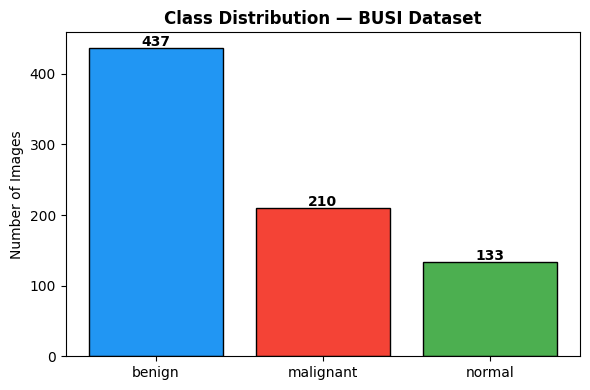

In [4]:
class BUSIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples      = []
        self.transform    = transform
        self.class_to_idx = {c: i for i, c in enumerate(CONFIG["class_names"])}

        for class_name in CONFIG["class_names"]:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            label = self.class_to_idx[class_name]
            for fname in sorted(os.listdir(class_dir)):
                if "_mask" in fname.lower():
                    continue
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    self.samples.append((os.path.join(class_dir, fname), label))

        print(f"Total samples loaded: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_labels(self):
        return [s[1] for s in self.samples]


dataset = BUSIDataset(CONFIG["data_dir"])
from collections import Counter
label_counts = Counter(dataset.get_labels())

print("\nClass distribution:")
for cls, idx in dataset.class_to_idx.items():
    print(f"  {cls:<12}: {label_counts[idx]} images")

fig, ax = plt.subplots(figsize=(6, 4))
counts = [label_counts[i] for i in range(CONFIG["num_classes"])]
colors = ["#2196F3", "#F44336", "#4CAF50"]
bars = ax.bar(CONFIG["class_names"], counts, color=colors, edgecolor="black")
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, c + 3, str(c),
            ha="center", fontweight="bold")
ax.set_title("Class Distribution — BUSI Dataset", fontweight="bold")
ax.set_ylabel("Number of Images")
plt.tight_layout()
plt.show()

## Transforms & Augmentation

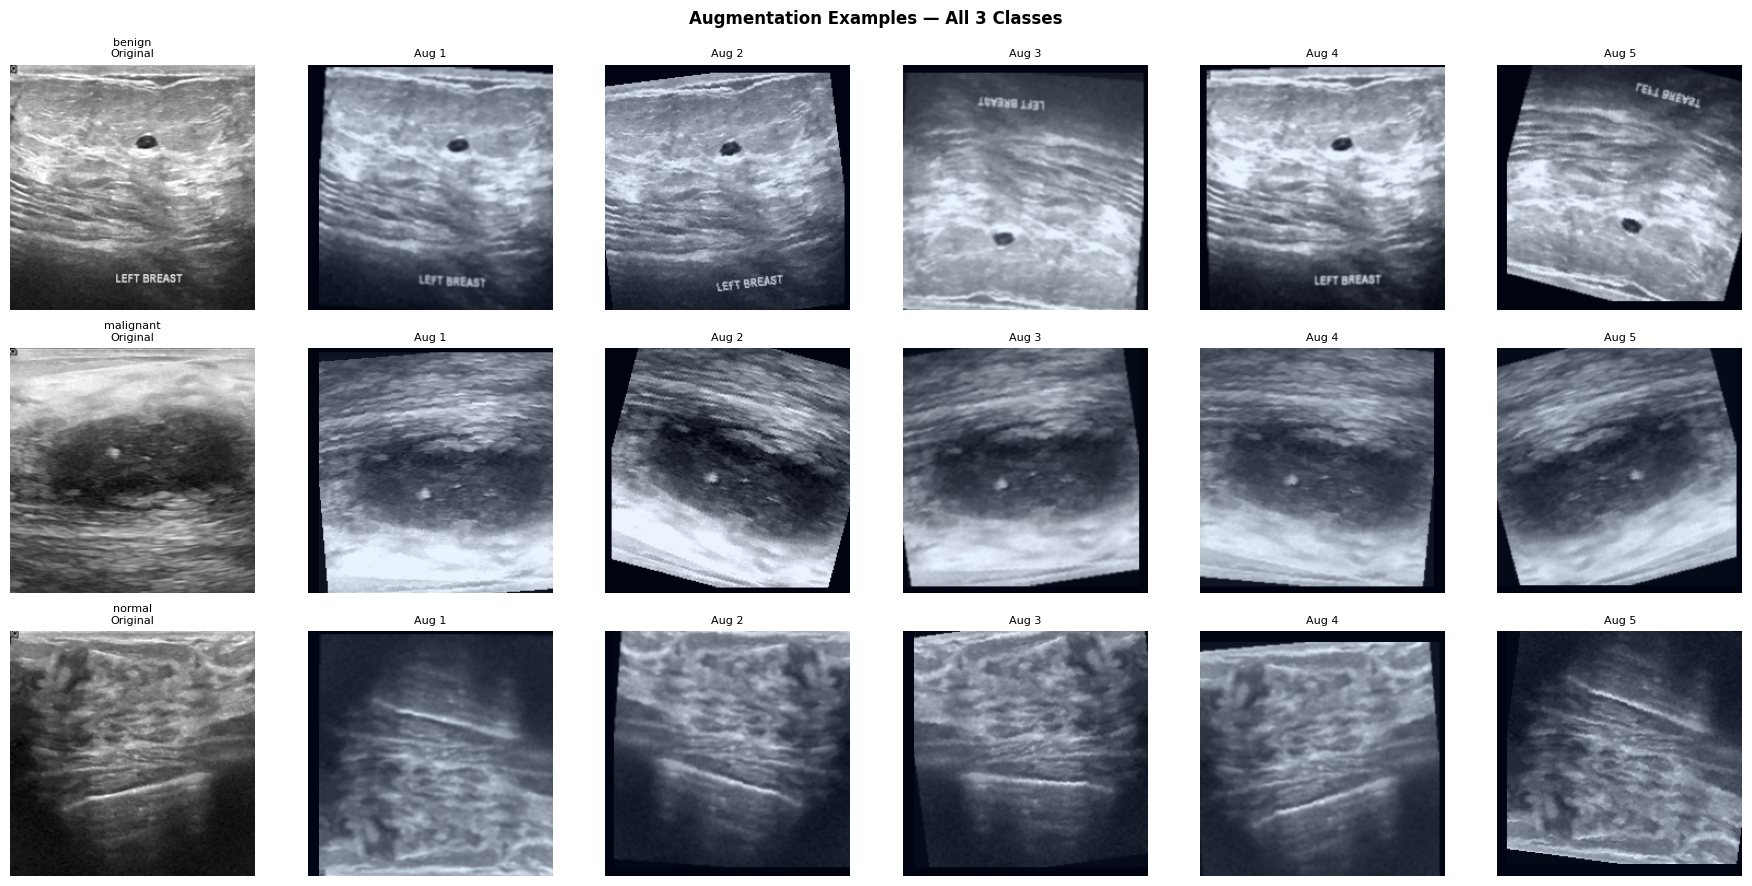

In [5]:
def get_transforms():
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    train_transform = transforms.Compose([
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    return train_transform, val_transform


# Visualise augmentation — one sample from each class
train_tf, _ = get_transforms()
fig, axes = plt.subplots(3, 6, figsize=(18, 9))

for row, class_name in enumerate(CONFIG["class_names"]):
    class_idx = dataset.class_to_idx[class_name]
    path = next(p for p, l in dataset.samples if l == class_idx)
    img  = Image.open(path).convert("RGB")

    axes[row, 0].imshow(img.resize((224, 224)))
    axes[row, 0].set_title(f"{class_name}\nOriginal", fontsize=8)
    axes[row, 0].axis("off")

    for col in range(1, 6):
        aug = train_tf(img).permute(1, 2, 0).numpy()
        aug = (aug - aug.min()) / (aug.max() - aug.min())
        axes[row, col].imshow(aug)
        axes[row, col].set_title(f"Aug {col}", fontsize=8)
        axes[row, col].axis("off")

plt.suptitle("Augmentation Examples — All 3 Classes", fontweight="bold")
plt.tight_layout()
plt.show()

## DataLoaders

In [6]:
class SubsetWithTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        path, label = self.dataset.samples[self.indices[i]]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


def build_dataloaders(data_dir):
    train_tf, val_tf = get_transforms()
    full_dataset = BUSIDataset(data_dir, transform=None)
    labels  = np.array(full_dataset.get_labels())
    indices = np.arange(len(full_dataset))

    # Stratified 70 / 15 / 15
    train_val_idx, test_idx = train_test_split(
        indices, test_size=0.15, stratify=labels, random_state=CONFIG["seed"]
    )
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.15 / 0.85,
        stratify=labels[train_val_idx],
        random_state=CONFIG["seed"],
    )

    train_set = SubsetWithTransform(full_dataset, train_idx, train_tf)
    val_set   = SubsetWithTransform(full_dataset, val_idx,   val_tf)
    test_set  = SubsetWithTransform(full_dataset, test_idx,  val_tf)

    print("Split summary (stratified):")
    for name, idx in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
        counts = {CONFIG["class_names"][k]: v
                  for k, v in zip(*np.unique(labels[idx], return_counts=True))}
        print(f"  {name:5s} ({len(idx):3d} images): {counts}")

    # WeightedRandomSampler — inverse frequency
    train_labels  = labels[train_idx]
    class_counts  = np.bincount(train_labels, minlength=CONFIG["num_classes"])
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = [class_weights[l] for l in train_labels]
    sampler = WeightedRandomSampler(sample_weights, len(train_set), replacement=True)

    print(f"\nSampler weights: {dict(zip(CONFIG['class_names'], class_weights.round(4)))}")
    print("  (higher = sampled more often per epoch)")

    train_loader = DataLoader(train_set, batch_size=CONFIG["batch_size"],
                              sampler=sampler, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_set,   batch_size=CONFIG["batch_size"],
                              shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=CONFIG["batch_size"],
                              shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders(CONFIG["data_dir"])
print(f"\nBatches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Total samples loaded: 780
Split summary (stratified):
  Train (545 images): {'benign': np.int64(305), 'malignant': np.int64(147), 'normal': np.int64(93)}
  Val   (118 images): {'benign': np.int64(66), 'malignant': np.int64(32), 'normal': np.int64(20)}
  Test  (117 images): {'benign': np.int64(66), 'malignant': np.int64(31), 'normal': np.int64(20)}

Sampler weights: {'benign': np.float64(0.0033), 'malignant': np.float64(0.0068), 'normal': np.float64(0.0108)}
  (higher = sampled more often per epoch)

Batches — Train: 18 | Val: 4 | Test: 4


## Focal Loss
FL(pt) = -α_t × (1 - pt)^γ × log(pt)

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = torch.tensor(alpha, dtype=torch.float32) if alpha else None

    def forward(self, inputs, targets):
        ce   = nn.functional.cross_entropy(inputs, targets, reduction="none")
        pt   = torch.exp(-ce)
        loss = (1 - pt) ** self.gamma * ce
        if self.alpha is not None:
            loss = self.alpha.to(inputs.device)[targets] * loss
        return loss.mean()


criterion = FocalLoss(gamma=CONFIG["focal_gamma"], alpha=CONFIG["focal_alpha"])
print("Focal Loss configured:")
for cls, a in zip(CONFIG["class_names"], CONFIG["focal_alpha"]):
    print(f"  {cls:<12}: α = {a}")

Focal Loss configured:
  benign      : α = 0.4
  malignant   : α = 0.4
  normal      : α = 0.2


## Model

In [8]:
def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    if CONFIG["freeze_layer4"]:
        # Only FC trainable
        for param in model.parameters():
            param.requires_grad = False
    else:
        # layer4 + FC trainable — balanced capacity
        for name, param in model.named_parameters():
            if "layer4" not in name and "fc" not in name:
                param.requires_grad = False

    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(CONFIG["dropout"]),   # 0.5
        nn.Linear(256, CONFIG["num_classes"]),
    )
    for param in model.fc.parameters():
        param.requires_grad = True

    return model


model = build_model()
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable : {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"Frozen    : {total - trainable:,}  ({100*(total-trainable)/total:.1f}%)")
print(f"\nClassifier head:")
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s] 


Trainable : 15,490,051  (64.5%)
Frozen    : 8,543,296  (35.5%)

Classifier head:
Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=3, bias=True)
)


## Optimizer & Scheduler

In [9]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

print("Optimizer : Adam")
print(f"  lr           = {CONFIG['learning_rate']}  (halved from 1e-4)")
print(f"  weight_decay = {CONFIG['weight_decay']}")
print(f"Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=3)")
print(f"Early stop: patience = {CONFIG['early_stop_patience']} epochs")

Optimizer : Adam
  lr           = 5e-05  (halved from 1e-4)
  weight_decay = 0.0001
Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=3)
Early stop: patience = 7 epochs


## Training Loop

In [10]:
def get_per_class_metrics(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            preds = model(images.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    recalls  = recall_score(all_labels, all_preds, average=None,
                            labels=list(range(CONFIG["num_classes"])), zero_division=0)
    return macro_f1, recalls


def _eval_loss_acc(model, loader, criterion, device):
    model.eval()
    run_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            run_loss += loss.item() * images.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return run_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None):
    device = CONFIG["device"]
    model.to(device)

    best_wts      = copy.deepcopy(model.state_dict())
    best_macro_f1 = 0.0
    es_counter    = 0
    stopped_epoch = CONFIG["num_epochs"]

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "val_macro_f1":         [],
        "val_recall_benign":    [],
        "val_recall_malignant": [],
        "val_recall_normal":    [],
    }

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * images.size(0)
            correct  += (out.argmax(1) == labels).sum().item()
            total    += labels.size(0)

        train_loss, train_acc = run_loss / total, correct / total

        # ── Validate ──────────────────────────────────────────────────────────
        val_loss, val_acc = _eval_loss_acc(model, val_loader, criterion, device)
        macro_f1, recalls = get_per_class_metrics(model, val_loader, device)

        if scheduler:
            scheduler.step(macro_f1)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(macro_f1)
        history["val_recall_benign"].append(recalls[0])
        history["val_recall_malignant"].append(recalls[1])
        history["val_recall_normal"].append(recalls[2])

        # Early stopping logic
        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_wts      = copy.deepcopy(model.state_dict())
            es_counter    = 0
            tag           = " ← best ✓"
        else:
            es_counter += 1
            tag         = f" (no improvement {es_counter}/{CONFIG['early_stop_patience']})"

        print(
            f"Epoch [{epoch:02d}/{CONFIG['num_epochs']}]  "
            f"Loss: {train_loss:.3f}/{val_loss:.3f}  "
            f"Acc: {train_acc:.3f}/{val_acc:.3f}  |  "
            f"MacroF1: {macro_f1:.3f}  "
            f"Recall B:{recalls[0]:.2f} M:{recalls[1]:.2f} N:{recalls[2]:.2f}"
            + tag
        )

        if es_counter >= CONFIG["early_stop_patience"]:
            print(f"\n Early stopping at epoch {epoch}")
            print(f"   Val Macro F1 did not improve for {CONFIG['early_stop_patience']} epochs")
            stopped_epoch = epoch
            break

    print(f"\nStopped at epoch : {stopped_epoch}/{CONFIG['num_epochs']}")
    print(f"Best Macro F1    : {best_macro_f1:.4f}")
    model.load_state_dict(best_wts)
    return model, history


model, history = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler
)

Epoch [01/40]  Loss: 0.144/0.129  Acc: 0.409/0.517  |  MacroF1: 0.378  Recall B:0.44 M:1.00 N:0.00 ← best ✓
Epoch [02/40]  Loss: 0.117/0.099  Acc: 0.558/0.627  |  MacroF1: 0.451  Recall B:0.70 M:0.88 N:0.00 ← best ✓
Epoch [03/40]  Loss: 0.095/0.107  Acc: 0.611/0.610  |  MacroF1: 0.494  Recall B:0.62 M:0.91 N:0.10 ← best ✓
Epoch [04/40]  Loss: 0.091/0.080  Acc: 0.732/0.746  |  MacroF1: 0.673  Recall B:0.89 M:0.69 N:0.35 ← best ✓
Epoch [05/40]  Loss: 0.082/0.081  Acc: 0.734/0.720  |  MacroF1: 0.703  Recall B:0.71 M:0.84 N:0.55 ← best ✓
Epoch [06/40]  Loss: 0.069/0.079  Acc: 0.804/0.788  |  MacroF1: 0.757  Recall B:0.83 M:0.84 N:0.55 ← best ✓
Epoch [07/40]  Loss: 0.074/0.078  Acc: 0.771/0.754  |  MacroF1: 0.656  Recall B:0.94 M:0.69 N:0.25 (no improvement 1/7)
Epoch [08/40]  Loss: 0.066/0.082  Acc: 0.818/0.729  |  MacroF1: 0.704  Recall B:0.73 M:0.88 N:0.50 (no improvement 2/7)
Epoch [09/40]  Loss: 0.066/0.077  Acc: 0.791/0.763  |  MacroF1: 0.726  Recall B:0.82 M:0.81 N:0.50 (no improveme

## Save Model

In [11]:
torch.save(model.state_dict(), "breast_ultrasound_model.pth")
print("Model saved → breast_ultrasound_model.pth")

# To reload:
# model = build_model()
# model.load_state_dict(torch.load("breast_ultrasound_model.pth", map_location=CONFIG["device"]))
# model.eval()

Model saved → breast_ultrasound_model.pth


## Training Curves

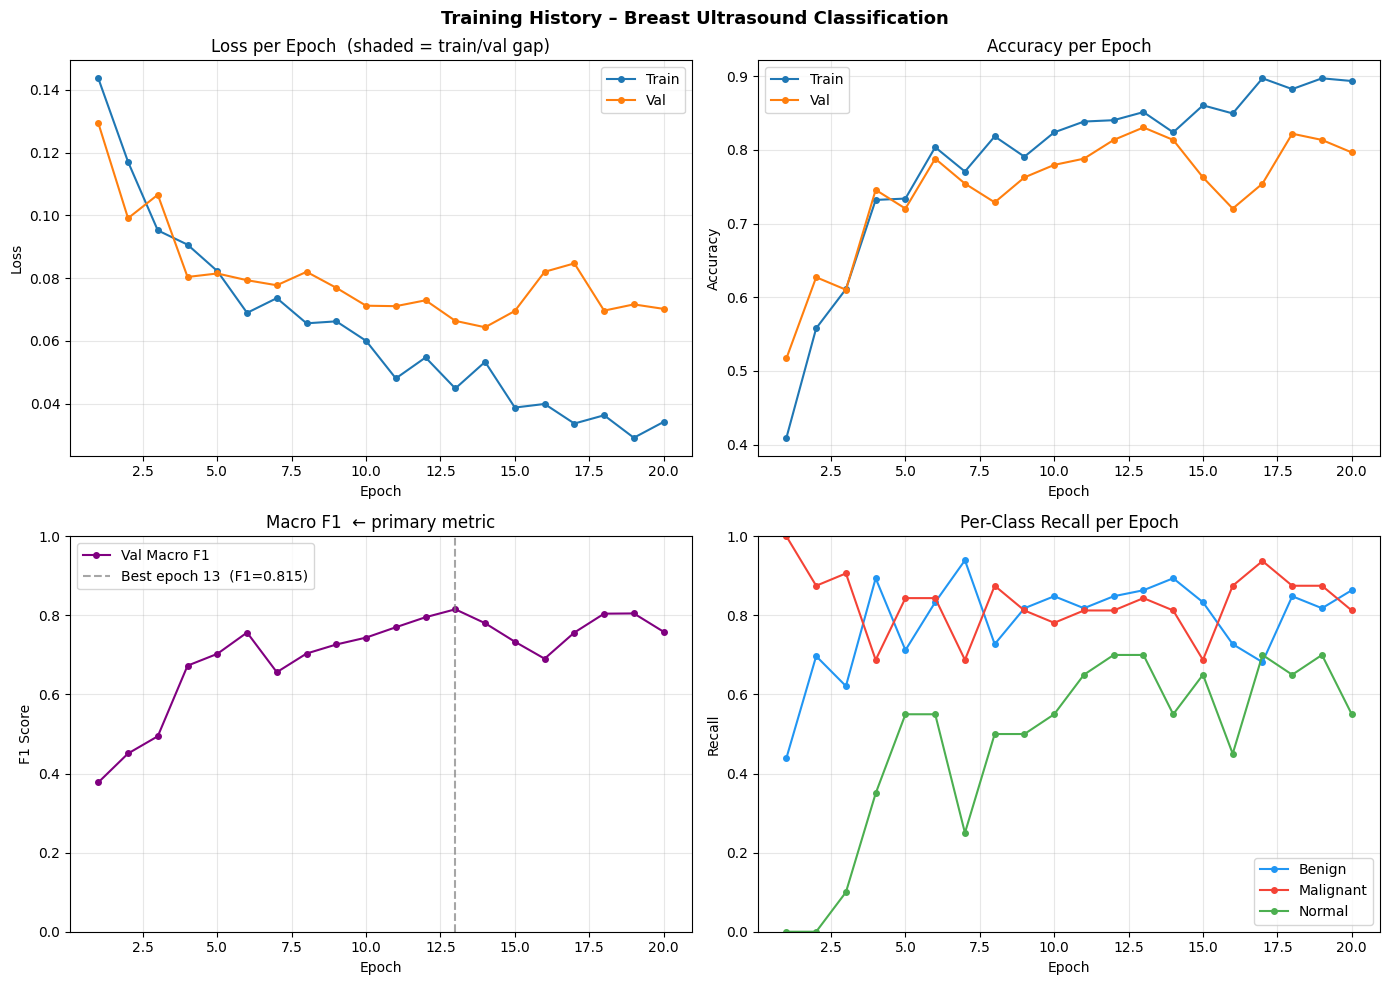

In [12]:
epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss — shaded gap
axes[0,0].plot(epochs, history["train_loss"], label="Train", marker="o", ms=4)
axes[0,0].plot(epochs, history["val_loss"],   label="Val",   marker="o", ms=4)
axes[0,0].set_title("Loss per Epoch  (shaded = train/val gap)")
axes[0,0].set_xlabel("Epoch"); axes[0,0].set_ylabel("Loss")
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Accuracy — shaded gap
axes[0,1].plot(epochs, history["train_acc"], label="Train", marker="o", ms=4)
axes[0,1].plot(epochs, history["val_acc"],   label="Val",   marker="o", ms=4)
axes[0,1].set_title("Accuracy per Epoch")
axes[0,1].set_xlabel("Epoch"); axes[0,1].set_ylabel("Accuracy")
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Macro F1
best_ep  = int(np.argmax(history["val_macro_f1"])) + 1
best_f1  = max(history["val_macro_f1"])
axes[1,0].plot(epochs, history["val_macro_f1"],
               color="purple", marker="o", ms=4, label="Val Macro F1")
axes[1,0].axvline(best_ep, color="gray", ls="--", alpha=0.7,
                  label=f"Best epoch {best_ep}  (F1={best_f1:.3f})")
axes[1,0].set_title("Macro F1  ← primary metric")
axes[1,0].set_xlabel("Epoch"); axes[1,0].set_ylabel("F1 Score")
axes[1,0].set_ylim(0, 1); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# Per-class Recall
axes[1,1].plot(epochs, history["val_recall_benign"],
               color="#2196F3", marker="o", ms=4, label="Benign")
axes[1,1].plot(epochs, history["val_recall_malignant"],
               color="#F44336", marker="o", ms=4, label="Malignant")
axes[1,1].plot(epochs, history["val_recall_normal"],
               color="#4CAF50", marker="o", ms=4, label="Normal")
axes[1,1].set_title("Per-Class Recall per Epoch")
axes[1,1].set_xlabel("Epoch"); axes[1,1].set_ylabel("Recall")
axes[1,1].set_ylim(0, 1); axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle("Training History – Breast Ultrasound Classification", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

## Final Evaluation on Test Set

In [13]:
def full_evaluation(model, test_loader):
    device = CONFIG["device"]
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            preds = model(images.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc      = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    recalls  = recall_score(all_labels, all_preds, average=None,
                            labels=list(range(CONFIG["num_classes"])), zero_division=0)
    precs    = precision_score(all_labels, all_preds, average=None,
                               labels=list(range(CONFIG["num_classes"])), zero_division=0)
    f1s      = f1_score(all_labels, all_preds, average=None,
                        labels=list(range(CONFIG["num_classes"])), zero_division=0)

    print("=" * 55)
    print(f"  Overall Accuracy          : {acc:.4f}")
    print(f"  Macro F1  (primary)       : {macro_f1:.4f}")
    print("-" * 55)
    print(f"  {'Class':<14} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(f"  {'-'*44}")
    for cls, p, r, f in zip(CONFIG["class_names"], precs, recalls, f1s):
        print(f"  {cls:<14} {p:>10.4f} {r:>10.4f} {f:>10.4f}")
    print("=" * 55)
    print("\nFull Classification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=CONFIG["class_names"]))
    return all_labels, all_preds


y_true, y_pred = full_evaluation(model, test_loader)

  Overall Accuracy          : 0.8718
  Macro F1  (primary)       : 0.8536
-------------------------------------------------------
  Class           Precision     Recall         F1
  --------------------------------------------
  benign             0.9483     0.8333     0.8871
  malignant          0.8378     1.0000     0.9118
  normal             0.7273     0.8000     0.7619

Full Classification Report:
              precision    recall  f1-score   support

      benign       0.95      0.83      0.89        66
   malignant       0.84      1.00      0.91        31
      normal       0.73      0.80      0.76        20

    accuracy                           0.87       117
   macro avg       0.84      0.88      0.85       117
weighted avg       0.88      0.87      0.87       117



## Confusion Matrix

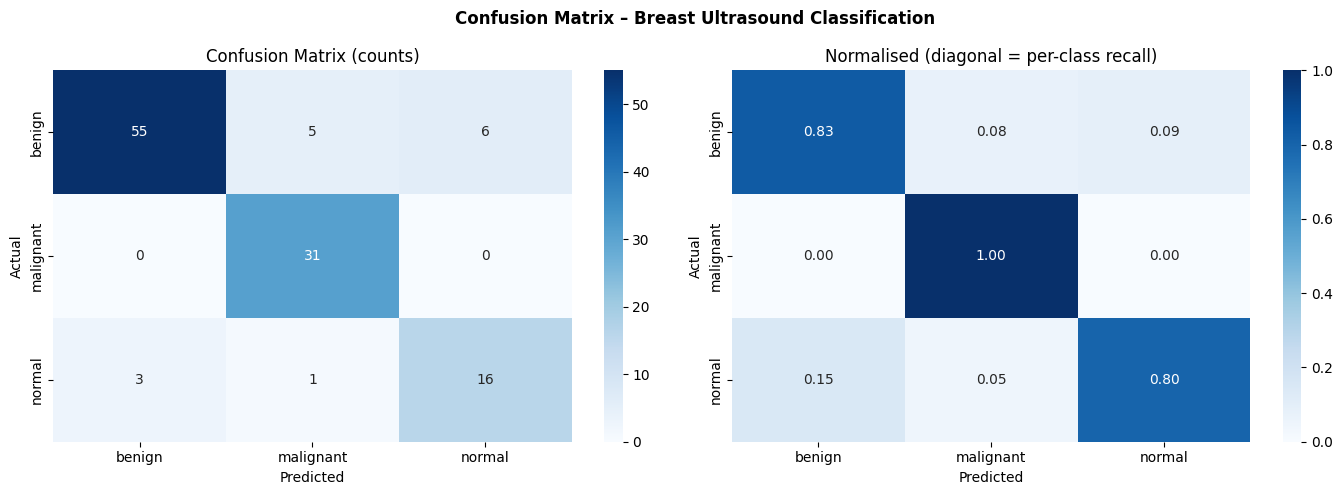


Misclassification Summary:
---------------------------------------------
  benign       — correct: 55/66  wrong: 11
    → predicted as malignant   : 5 times
    → predicted as normal      : 6 times
  malignant    — correct: 31/31  wrong: 0
  normal       — correct: 16/20  wrong: 4
    → predicted as benign      : 3 times
    → predicted as malignant   : 1 times


In [14]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CONFIG["class_names"],
            yticklabels=CONFIG["class_names"], ax=axes[0])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix (counts)")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CONFIG["class_names"],
            yticklabels=CONFIG["class_names"], ax=axes[1])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title("Normalised (diagonal = per-class recall)")

plt.suptitle("Confusion Matrix – Breast Ultrasound Classification", fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("\nMisclassification Summary:")
print("-" * 45)
for i, cls in enumerate(CONFIG["class_names"]):
    total_cls = cm[i].sum()
    correct   = cm[i, i]
    print(f"  {cls:<12} — correct: {correct}/{total_cls}  wrong: {total_cls - correct}")
    for j, pred_cls in enumerate(CONFIG["class_names"]):
        if i != j and cm[i, j] > 0:
            print(f"    → predicted as {pred_cls:<12}: {cm[i, j]} times")

## Single Image Inference

 Sample Predictions — One per Class 

Actual: BENIGN


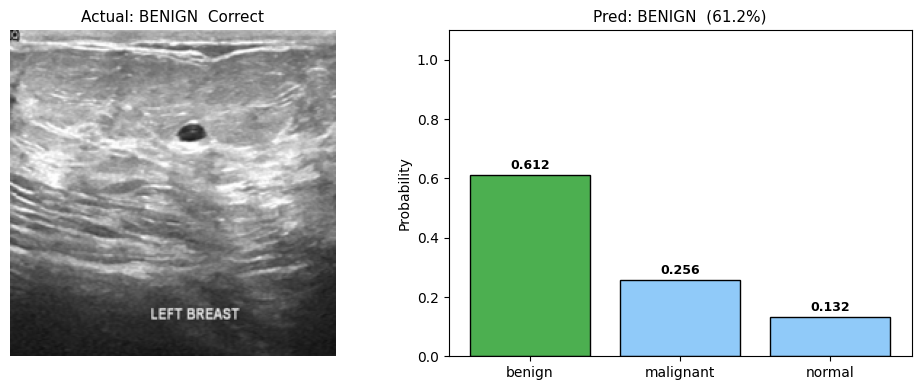

  Pred: BENIGN       (61.24%)
Actual: MALIGNANT


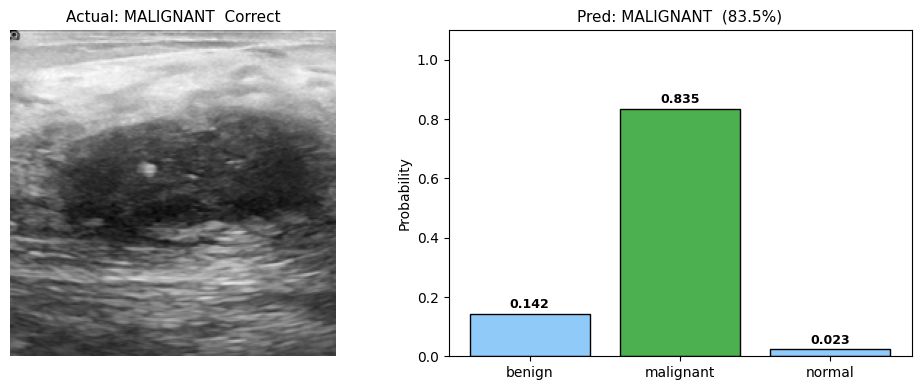

  Pred: MALIGNANT    (83.53%)
Actual: NORMAL


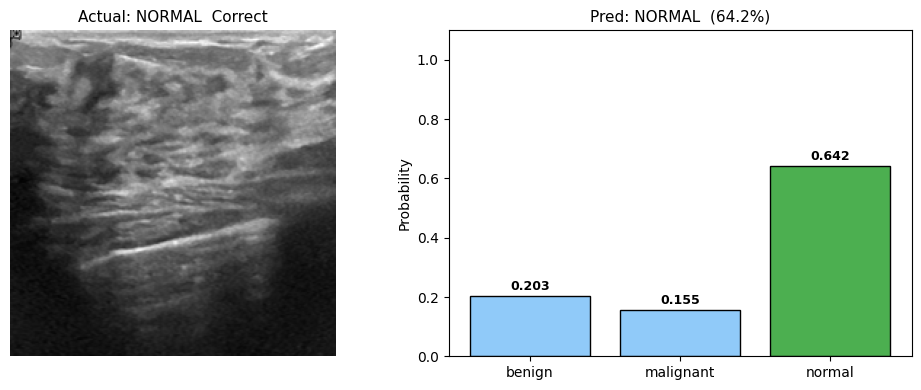

  Pred: NORMAL       (64.21%)


In [15]:
def predict_single_image(model, image_path, actual_label=None):
    _, val_tf = get_transforms()
    image  = Image.open(image_path).convert("RGB")
    tensor = val_tf(image).unsqueeze(0).to(CONFIG["device"])

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

    pred_idx   = probs.argmax()
    pred_label = CONFIG["class_names"][pred_idx]
    correct    = (pred_label == actual_label) if actual_label else None

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image.resize((224, 224)), cmap="gray")
    title = f"Actual: {actual_label.upper()}" if actual_label else "Input"
    if correct is not None:
        title += f"  {'Correct' if correct else 'Wrong'}"
    axes[0].set_title(title, fontsize=11); axes[0].axis("off")

    bar_colors = []
    for i in range(len(CONFIG["class_names"])):
        if i == pred_idx:
            bar_colors.append("#4CAF50" if correct != False else "#F44336")
        else:
            bar_colors.append("#90CAF9")

    bars = axes[1].bar(CONFIG["class_names"], probs, color=bar_colors, edgecolor="black")
    axes[1].set_ylabel("Probability")
    axes[1].set_title(f"Pred: {pred_label.upper()}  ({probs[pred_idx]:.1%})", fontsize=11)
    axes[1].set_ylim(0, 1.1)
    for bar, p in zip(bars, probs):
        axes[1].text(bar.get_x() + bar.get_width()/2, p + 0.02,
                     f"{p:.3f}", ha="center", fontweight="bold", fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f"  Pred: {pred_label.upper():<12} ({probs[pred_idx]:.2%})")
    return pred_label, probs


print(" Sample Predictions — One per Class \n")
for class_name in CONFIG["class_names"]:
    class_idx   = dataset.class_to_idx[class_name]
    sample_path = next(p for p, l in dataset.samples if l == class_idx)
    print(f"Actual: {class_name.upper()}")
    predict_single_image(model, sample_path, actual_label=class_name)